# How Do People Get to Work?
### Exploratory Data Analysis using the NTAD Means of Transportation to Work dataset


In [10]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 4)

### Step 1 - Importing the Dataset

In [11]:
df = pd.read_csv("./NTAD_Means_of_Transportation_to_Work_8562942963264034184.csv")

In [8]:
df.describe

<bound method NDFrame.describe of        OBJECTID        GEOID       ALAND    AWATER  STATEFP  COUNTYFP  \
0             1   4001945001   109611703     39384        4         1   
1             2   4001945002  1163931489    709218        4         1   
2             3   4001945100  1614930614   1021494        4         1   
3             4   4001970201  1623610491   2026508        4         1   
4             5   4001970202 -2147483648   3378971        4         1   
...         ...          ...         ...       ...      ...       ...   
85111     85112  29109470401    15506137     26831       29       109   
85112     85113  29109470402    95301655    301766       29       109   
85113     85114  29177080100   734934999   7810890       29       177   
85114     85115  29185480100   507556786  21205224       29       185   
85115     85116  29185480200   800112408  20731506       29       185   

       TRACTCE  TRACTID              NAMELSAD  \
0       945001  9450.01  Census Tract 94

### Understanding the Dataset

In [ ]:
df.dtypes

OBJECTID                                                        int64
GEOID                                                           int64
ALAND                                                           int64
AWATER                                                          int64
STATEFP                                                         int64
COUNTYFP                                                        int64
TRACTCE                                                         int64
TRACTID                                                       float64
NAMELSAD                                                          str
NAME                                                              str
Total workers                                                   int64
Workers traveling by car, truck, or van                         int64
Workers traveling by car, truck, or van - drove alone           int64
Workers traveling by car, truck, or van - carpooled             int64
Workers traveling by

In [9]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 85116
Columns: 29


### Cleaning the dataset

In [10]:
print("Tracts with zero workers:", len(df[df["Total workers"] == 0]))
print("Missing values in % columns:", df["% of workers working from home"].isnull().sum())

Tracts with zero workers: 733
Missing values in % columns: 733


In [11]:
df_clean = df[df["Total workers"] > 0]
print("Rows after cleaning:", len(df_clean))

Rows after cleaning: 84383


### Extracting the dataset

In [ ]:
df_clean["state"] = df_clean["NAME"].str.split(";").str[-1].str.strip()

df_clean["state"].value_counts()


state
California              9057
Texas                   6843
New York                5272
Florida                 5079
Pennsylvania            3405
Illinois                3259
Ohio                    3151
Michigan                2903
Georgia                 2782
North Carolina          2645
New Jersey              2167
Virginia                2164
Washington              1769
Arizona                 1737
Indiana                 1685
Tennessee               1681
Missouri                1650
Massachusetts           1600
Wisconsin               1524
Minnesota               1498
Maryland                1456
Colorado                1432
Alabama                 1430
Louisiana               1365
South Carolina          1309
Kentucky                1300
Oklahoma                1199
Oregon                   992
Puerto Rico              919
Iowa                     894
Connecticut              874
Mississippi              870
Arkansas                 822
Kansas                   818
Nevada  

### National Averages

In [13]:
pct_modes = [
    "% of workers traveling by car, truck, or van",
    "% of workers traveling by public transportation",
    "% of workers traveling by walking",
    "% of workers traveling by bicycle",
    "% of workers working from home",
]

df_clean[pct_modes].mean()

% of workers traveling by car, truck, or van       79.180833
% of workers traveling by public transportation     3.604500
% of workers traveling by walking                   2.618849
% of workers traveling by bicycle                   0.448215
% of workers working from home                     12.624619
dtype: float64

### Visualizing the Data

Text(0, 0.5, 'Average % of workers')

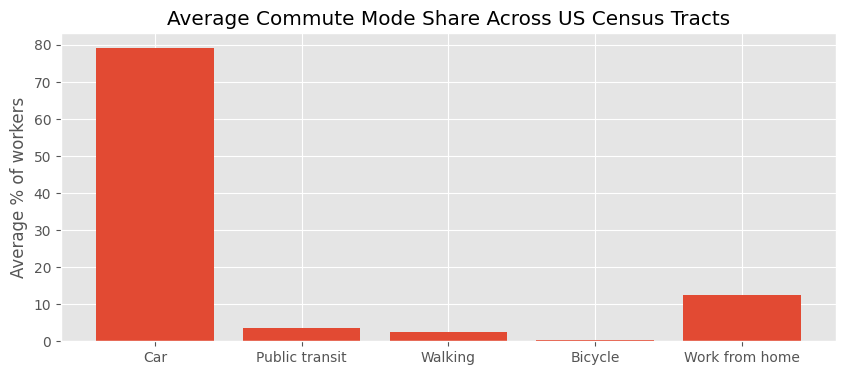

In [14]:
averages = df_clean[pct_modes].mean()
labels = ["Car", "Public transit", "Walking", "Bicycle", "Work from home"]

plt.bar(labels, averages)
plt.title("Average Commute Mode Share Across US Census Tracts")
plt.ylabel("Average % of workers")

### Question for Analysis: Does high remote work correlate to low public transit use?

In [13]:
plt.scatter(
    df_clean["% of workers working from home"],
    df_clean["% of workers traveling by public transportation"]
)
plt.xlabel("% working from home")
plt.ylabel("% using public transit")
plt.title("Work-from-Home vs. Public Transit Use (each dot = one census tract)")

NameError: name 'df_clean' is not defined

In [16]:
corr = df_clean[["% of workers working from home",
                  "% of workers traveling by public transportation"]].corr()
print(corr)

                                                 % of workers working from home  \
% of workers working from home                                         1.000000   
% of workers traveling by public transportation                        0.072836   

                                                 % of workers traveling by public transportation  
% of workers working from home                                                          0.072836  
% of workers traveling by public transportation                                         1.000000  


#### A correlation of 0.073 means there's almost no linear relationship between the two variables.This raises a follow-up question:  is remote work concentrated in areas with low public transit options?  Or is displacement happening in high-transit states, just hidden by national averages?

### Comparing States

In [17]:
state_avg = df_clean.groupby("state")["% of workers traveling by public transportation"].mean()

print("Top 5 states by transit use:")
print(state_avg.sort_values(ascending=False).head(5))

print("\nBottom 5 states by transit use:")
print(state_avg.sort_values().head(5))

Top 5 states by transit use:
state
District of Columbia    22.481262
New York                21.906239
New Jersey               8.674236
Massachusetts            7.423919
Illinois                 6.767423
Name: % of workers traveling by public transportation, dtype: float64

Bottom 5 states by transit use:
state
Mississippi     0.293195
Oklahoma        0.327590
North Dakota    0.364518
Arkansas        0.388869
Alabama         0.442573
Name: % of workers traveling by public transportation, dtype: float64


Text(0.5, 0, 'Average % of workers using public transit')

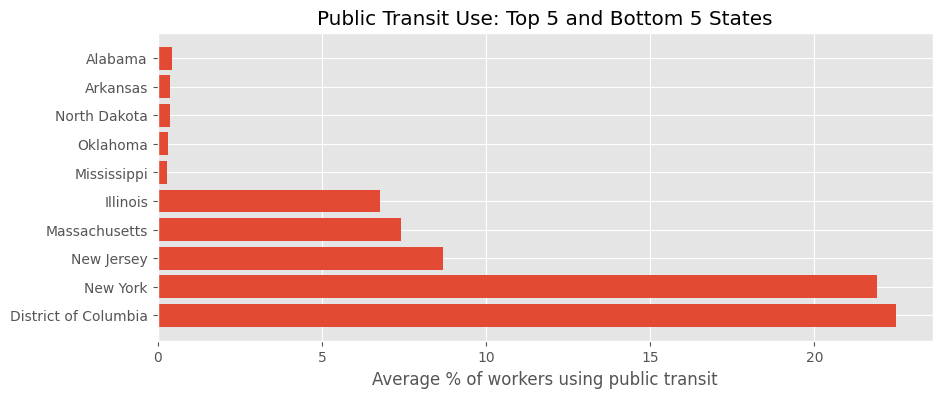

In [18]:
top5 = state_avg.sort_values(ascending=False).head(5)
bottom5 = state_avg.sort_values().head(5)
comparison = pd.concat([top5, bottom5])

plt.barh(comparison.index, comparison.values)
plt.title("Public Transit Use: Top 5 and Bottom 5 States")
plt.xlabel("Average % of workers using public transit")

### Testing the hypothesis - is there a stronger correlation in high transit states?

In [19]:
high_transit_states = ["New York", "New Jersey", "Massachusetts", "Illinois", "District of Columbia"]
df_ht = df_clean[df_clean["state"].isin(high_transit_states)]

print("Tracts in high-transit states:", len(df_ht))

Tracts in high-transit states: 12504


In [20]:
corr_national = df_clean[["% of workers working from home",
                           "% of workers traveling by public transportation"]].corr()

corr_ht = df_ht[["% of workers working from home",
                  "% of workers traveling by public transportation"]].corr()

print(corr_national)
print(corr_ht)

                                                 % of workers working from home  \
% of workers working from home                                         1.000000   
% of workers traveling by public transportation                        0.072836   

                                                 % of workers traveling by public transportation  
% of workers working from home                                                          0.072836  
% of workers traveling by public transportation                                         1.000000  
                                                 % of workers working from home  \
% of workers working from home                                         1.000000   
% of workers traveling by public transportation                        0.046628   

                                                 % of workers traveling by public transportation  
% of workers working from home                                                          0.046628  
% of 

In [21]:
for state in high_transit_states:
    sub = df_clean[df_clean["state"] == state]
    r = sub[["% of workers working from home",
             "% of workers traveling by public transportation"]].corr()
    print(f"{state} {r}")

New York                                                  % of workers working from home  \
% of workers working from home                                         1.000000   
% of workers traveling by public transportation                        0.034351   

                                                 % of workers traveling by public transportation  
% of workers working from home                                                          0.034351  
% of workers traveling by public transportation                                         1.000000  
New Jersey                                                  % of workers working from home  \
% of workers working from home                                         1.000000   
% of workers traveling by public transportation                        0.089984   

                                                 % of workers traveling by public transportation  
% of workers working from home                                                      

#### DC stands out with r = -0.472. within DC, tracts with more remote workers tend to have noticeably lower transit use, however, a positive relationship exists for all other states, with different levels of strength. We need more longitudnal data to see why DC tracts are different than other states, and also whether all states have experienced these levels of correlation over a period of time.

#### Another Limitation: state wide data, not city wide